In [1]:
# ============================================
# DRIFTING ORACLE
# PHASE 1 — BASELINE MODEL
# STEP 5 — MODELING
# ============================================

import pandas as pd
import numpy as np
import joblib

from pathlib import Path

print("Baseline modeling notebook started.")

Baseline modeling notebook started.


In [2]:
#Load the dataset and create the same split

from sklearn.model_selection import train_test_split


DATA_PATH = Path("../data/application_train.csv")


df = pd.read_csv(DATA_PATH)


# Separate target and remove applicant ID.
X = df.drop(columns=["TARGET", "SK_ID_CURR"]).copy()
y = df["TARGET"].copy()


# Correct the known Home Credit sentinel value.
X["DAYS_EMPLOYED"] = X["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)


# IMPORTANT:
# Same split configuration as previous notebooks.
# This guarantees reproducibility.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training:", X_train.shape)
print("Validation:", X_valid.shape)

Training: (246008, 120)
Validation: (61503, 120)


In [6]:
#Apply our 10 engineered features

def engineer_features(df):
    """
    Apply the exact feature engineering used
    for our baseline model.
    """

    data = df.copy()

    # Age in years
    data["AGE_YEARS"] = -data["DAYS_BIRTH"] / 365.25

    # Employment duration in years
    data["EMPLOYED_YEARS"] = -data["DAYS_EMPLOYED"] / 365.25

    def safe_divide(a, b):
        return a / b.replace(0, np.nan)

    # Credit burden relative to income
    data["CREDIT_TO_INCOME"] = safe_divide(
        data["AMT_CREDIT"],
        data["AMT_INCOME_TOTAL"]
    )

    # Annuity burden relative to income
    data["ANNUITY_TO_INCOME"] = safe_divide(
        data["AMT_ANNUITY"],
        data["AMT_INCOME_TOTAL"]
    )

    # Loan amount relative to annuity
    data["CREDIT_TO_ANNUITY"] = safe_divide(
        data["AMT_CREDIT"],
        data["AMT_ANNUITY"]
    )

    # Goods price relative to credit
    data["GOODS_TO_CREDIT"] = safe_divide(
        data["AMT_GOODS_PRICE"],
        data["AMT_CREDIT"]
    )

    # Income relative to household size
    data["INCOME_PER_FAMILY_MEMBER"] = safe_divide(
        data["AMT_INCOME_TOTAL"],
        data["CNT_FAM_MEMBERS"]
    )

    # Income relative to number of children
    data["INCOME_PER_CHILD"] = (
        data["AMT_INCOME_TOTAL"] /
        (data["CNT_CHILDREN"] + 1)
    )

    # Mean of available external credit scores
    external_sources = [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]

    data["EXT_SOURCE_MEAN"] = data[
        external_sources
    ].mean(axis=1)

    # Maximum available external score
    data["EXT_SOURCE_MAX"] = data[
        external_sources
    ].max(axis=1)

    return data

In [7]:
X_train_fe = engineer_features(X_train)
X_valid_fe = engineer_features(X_valid)

print("Training after feature engineering:", X_train_fe.shape)
print("Validation after feature engineering:", X_valid_fe.shape)

Training after feature engineering: (246008, 130)
Validation after feature engineering: (61503, 130)


In [8]:
#Recreate preprocessing 

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = X_train_fe.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Fit ONLY on training data.
preprocessor.fit(X_train_fe)

X_train_processed = preprocessor.transform(X_train_fe)
X_valid_processed = preprocessor.transform(X_valid_fe)

print("Processed training:", X_train_processed.shape)
print("Processed validation:", X_valid_processed.shape)

Processed training: (246008, 254)
Processed validation: (61503, 254)


In [ ]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.0


In [10]:
#create a baseline model

from xgboost import XGBClassifier

baseline_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=30
)

print("Baseline XGBoost model created.")

Baseline XGBoost model created.


In [11]:
baseline_model.fit(
    X_train_processed,
    y_train,

    # Validation data is used for early stopping.
    # It is NOT used to fit the model's parameters.
    eval_set=[
        (X_valid_processed, y_valid)
    ],

    verbose=50
)

[0]	validation_0-auc:0.72491
[50]	validation_0-auc:0.75363
[100]	validation_0-auc:0.76157
[150]	validation_0-auc:0.76489
[200]	validation_0-auc:0.76674
[250]	validation_0-auc:0.76809
[300]	validation_0-auc:0.76852
[350]	validation_0-auc:0.76902
[400]	validation_0-auc:0.76927
[450]	validation_0-auc:0.76985
[485]	validation_0-auc:0.76966


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
#Checkl best no of trees 
print("Best iteration:", baseline_model.best_iteration)
print("Best validation AUC:", baseline_model.best_score)

Best iteration: 455
Best validation AUC: 0.7699801632403869


In [13]:
#Generate baseline prediction

# Probability that an applicant belongs to TARGET = 1.
y_valid_proba = baseline_model.predict_proba(
    X_valid_processed
)[:, 1]

print("First 10 predicted probabilities:")
print(y_valid_proba[:10])

First 10 predicted probabilities:
[0.05799618 0.05578236 0.27497342 0.07770868 0.08382978 0.09124032
 0.01173929 0.00734884 0.421801   0.07926009]


In [14]:
#save the baslien model 

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    baseline_model,
    MODEL_DIR / "baseline_xgboost.joblib"
)

joblib.dump(
    preprocessor,
    MODEL_DIR / "baseline_preprocessor.joblib"
)

print("Baseline model saved.")
print("Baseline preprocessor saved.")

Baseline model saved.
Baseline preprocessor saved.


Model evaluation 

In [16]:
#Baseline Evaluation

# ============================================
# STEP 6 — BASELINE MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Evaluation tools loaded.")

Evaluation tools loaded.


In [17]:
# ROC-AUC measures how well the model ranks
# default applicants above non-default applicants.

roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba
)

# PR-AUC is especially important here because
# defaults are only about 8% of the dataset.
pr_auc = average_precision_score(
    y_valid,
    y_valid_proba
)

print(f"Validation ROC-AUC : {roc_auc:.4f}")
print(f"Validation PR-AUC  : {pr_auc:.4f}")

Validation ROC-AUC : 0.7700
Validation PR-AUC  : 0.2601


In [18]:
# ============================================
# STEP 7 — CREATE BASELINE REFERENCE STATE
# ============================================

reference_predictions = pd.Series(
    y_valid_proba,
    name="prediction_probability"
)

print(reference_predictions.describe())

count    61503.000000
mean         0.080097
std          0.084237
min          0.000958
25%          0.026423
50%          0.050719
75%          0.100803
max          0.733463
Name: prediction_probability, dtype: float64


In [19]:
prediction_reference = {
    "mean": float(reference_predictions.mean()),
    "std": float(reference_predictions.std()),
    "min": float(reference_predictions.min()),
    "max": float(reference_predictions.max()),
    "p25": float(reference_predictions.quantile(0.25)),
    "p50": float(reference_predictions.quantile(0.50)),
    "p75": float(reference_predictions.quantile(0.75)),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc)
}

prediction_reference

{'mean': 0.08009732514619827,
 'std': 0.08423727005720139,
 'min': 0.0009579129982739687,
 'max': 0.73346346616745,
 'p25': 0.026422967202961445,
 'p50': 0.05071945860981941,
 'p75': 0.10080339387059212,
 'roc_auc': 0.7699801632403869,
 'pr_auc': 0.2601053041291099}

In [20]:
import json

with open(
    "../models/baseline_reference_metrics.json",
    "w"
) as f:
    json.dump(prediction_reference, f, indent=4)

print("Baseline reference metrics saved.")

Baseline reference metrics saved.


SHAP

In [22]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/41.9 MB 5.6 MB/s eta 0:00:08
   - -------------------------------------- 1.8/41.9 MB 4.6 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/41.9 MB 4.3 MB/s eta 0:00:10
   --- ------------------------------------ 3.4/41.9 MB 4.2 MB/s eta 0:00:10
   ---- ----------------------------------- 4.2/41.9 MB 4.0 MB/s eta 0:00:10
   ----- ---------------------------------- 5.2/41.9 MB 4.1 MB/s eta 0:00:09
   ----- ---------------------------------- 5.8/41.9 MB 4.0 MB/s eta 0:00:09
   ------ --------------------------------- 6.8/41.9 MB 4.0 MB/s eta 0:00:09
   ------- -------------------------------- 7.6/41.9 MB 4.0 MB/s eta 0:00:09
   -------- ------------------------------- 8.4/41.9 MB 4.0 MB/s eta 0:00:09
   -------- ------------------------------- 9.2/41.9 MB 4.0 MB/s eta 0:00:09
   --


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\nitingowda\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
import shap
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

C:\Users\nitingowda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


In [25]:
# SHAP on the entire validation set is unnecessary for our MVP.
# A representative sample is enough to understand model behaviour.

sample_size = 2000

sample_indices = np.random.RandomState(42).choice(
    X_valid_processed.shape[0],
    size=sample_size,
    replace=False
)

X_shap = X_valid_processed[sample_indices]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (2000, 254)


In [26]:
#shap explainer 

explainer = shap.TreeExplainer(baseline_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 254)


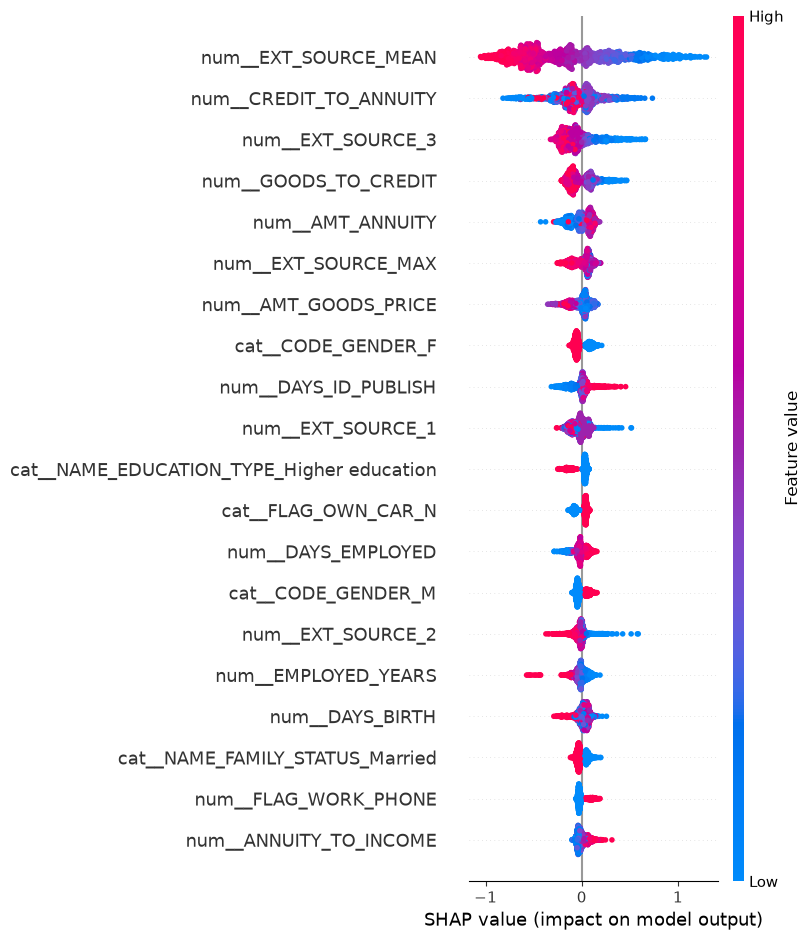

In [27]:
# Shows which model features influence predictions most strongly overall.

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=preprocessor.get_feature_names_out(),
    show=True
)

In [28]:
#Save SHAP

feature_names = preprocessor.get_feature_names_out()

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.head(20)

,feature,mean_abs_shap
112,num__EXT_SOURCE_MEAN,0.454464
108,num__CREDIT_TO_ANNUITY,0.162520
29,num__EXT_SOURCE_3,0.137167
109,num__GOODS_TO_CREDIT,0.105693
3,num__AMT_ANNUITY,0.082854
113,num__EXT_SOURCE_MAX,0.079115
4,num__AMT_GOODS_PRICE,0.070788
116,cat__CODE_GENDER_F,0.067740
9,num__DAYS_ID_PUBLISH,0.066880
27,num__EXT_SOURCE_1,0.063314


In [29]:
#save it 

shap_importance.to_csv(
    "../models/baseline_shap_importance.csv",
    index=False
)

print("SHAP importance saved.")

SHAP importance saved.
